# Causation Coding: formação em oratória

Este notebook recompila o projeto com `synesis.load` e reproduz a etapa de análise agregada
das atribuições causais descrita por Saldaña (2013). Os dados são fictícios e redigidos em português.

## Fundamentação teórica

### Causation Coding (Saldaña, 2013)

O **Causation Coding** é um método de codificação de primeira volta descrito por Saldaña (2013,
pp. 163–175). Seu objetivo é localizar, extrair e/ou inferir **crenças causais** em dados qualitativos
— entrevistas, notas de campo, respostas abertas — identificando o que os participantes acreditam
sobre eventos e suas causas (Munton et al., 1999, pp. 5–6).

O método integra quatro fontes principais:

| Fonte | Contribuição |
|---|---|
| Munton et al. (1999) | Leeds Attributional Coding System: causa, resultado e elo entre eles |
| Franzosi (2010) | Análise narrativa quantitativa: triplet *razão → ação → resultado* |
| Maxwell (2012) | Princípios de causalidade em pesquisa qualitativa |
| Morrison (2009) | Ênfase em mecanismos, intenções e agência individual |
| Miles & Huberman (1994) | Estratégias analíticas explanatórias; matrizes antecedente-mediador-resultado |

### Estrutura tripartite

Três fontes convergem para o mesmo modelo de análise (Saldaña, 2013, p. 164):

```
CODE 1 (antecedente)  →  CODE 2 (mediador)  →  CODE 3 (resultado)
```

> "Narrative sequences imply causal sequences." (Franzosi, 2010, p. 13)

Como múltiplas causas e múltiplos resultados são possíveis, a estrutura admite subconjuntos:

```
CODE 1A + CODE 1B  →  CODE 2  →  CODE 3A + CODE 3B + CODE 3C
```

Quando o mediador não está explícito na narrativa, o analista deve inferi-lo
a partir do contexto ou retornar aos participantes para dados adicionais
(Saldaña, 2013, p. 164).

### Dimensões de causalidade (Leeds Attributional Coding System)

Munton et al. (1999) operacionalizaram cinco dimensões para qualificar atribuições causais
(Saldaña, 2013, p. 164–165):

- **Interno / externo** — a causa vem da própria pessoa ou de fatores externos
- **Estável / instável** — previsibilidade do resultado ao longo do tempo
- **Global / específico** — amplitude do efeito (muitas situações vs. situação particular)
- **Pessoal / universal** — singularidade da situação para o indivíduo
- **Controlável / incontrolável** — percepção de controle sobre causa, elo e resultado

### Categorias analíticas de resultado

Saldaña (2013, pp. 169–171) propõe organizar os códigos em uma matriz
*antecedente → mediador → resultado* e reagrupar os resultados em categorias temáticas.
Neste projeto, as sete categorias derivam diretamente do array analítico do exemplo empírico
de McCammon & Saldaña (2011) sobre oratória no ensino médio:

| Categoria | Descrição |
|---|---|
| `preparação_profissional` | Habilidades transferidas para estudo, trabalho e carreira |
| `habilidades_apresentação` | Comunicação oral, argumentação e apresentação |
| `habilidades_liderança` | Coordenação, negociação e condução de grupos |
| `confiança` | Confiança, compostura e superação de inibições |
| `ganhos_competição` | Vitórias, reconhecimento e memórias de competição |
| `pertencimento_social` | Amizades, aceitação e relações interpessoais |
| `efeitos_pessoais` | Autoestima, disciplina e ética de trabalho |

As duas macrocategorias do estudo original (Saldaña, 2013, p. 171) são:
- **Preparação para o trabalho** (*Workforce Preparation*): habilidades de carreira, apresentação e liderança
- **Preparação para a vida** (*Lifeforce Preparation*): confiança, pertencimento, ganhos de competição e efeitos pessoais

### Vocabulário de relações causais

As relações utilizadas nas cadeias deste projeto foram derivadas das dimensões do LACS
e das categorias analíticas de Miles & Huberman (1994), com precisão semântica aumentada
para eliminar ambiguidade entre amplificação e atenuação:

| Relação | Definição | Fundamento |
|---|---|---|
| `CAUSA` | Um fator produz diretamente outro fator | Elo direto de geração (Munton et al., 1999, p. 9) |
| `HABILITA` | Um fator cria condições para que outro se desenvolva | Variável antecedente que possibilita o mediador (Miles & Huberman, 1994, p. 157) |
| `AMPLIFICA` | Um fator reforça ou intensifica outro já presente | Dimensão controlável/estável com efeito positivo (Munton et al., 1999, p. 9) |
| `ATENUA` | Um fator enfraquece ou reduz a intensidade de outro | Dimensão controlável/estável com efeito negativo (Morrison, 2009, p. 116) |
| `RESTRINGE` | Um fator bloqueia ou impede o desenvolvimento de outro | Dimensão incontrolável ou barreira (Miles & Huberman, 1994, p. 143) |

### Referências

- Franzosi, R. (2010). *Quantitative narrative analysis*. SAGE.
- Maxwell, J. A. (2012). *A realist approach for qualitative research*. SAGE.
- Miles, M. B., & Huberman, A. M. (1994). *Qualitative data analysis* (2nd ed.). SAGE.
- Morrison, K. (2009). *Causation in educational research*. Routledge.
- Munton, A. G., Silvester, J., Stratton, P., & Hanks, H. (1999). *Attributions in action*. Wiley.
- Saldaña, J. (2013). *The coding manual for qualitative researchers* (2nd ed., pp. 163–175). SAGE.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import pandas as pd
import synesis
from IPython.display import display


def localizar_projeto(inicio: Path) -> Path:
    for base in (inicio, *inicio.parents):
        candidatos = (base, base / "Education/Causation_Coding_Oratoria")
        for candidato in candidatos:
            if (candidato / "project.synp").is_file():
                return candidato
    raise FileNotFoundError("Diretório do projeto Causation Coding não encontrado.")


def ler_texto(caminho: Path) -> str:
    return caminho.read_text(encoding="utf-8")


projeto = localizar_projeto(Path.cwd())
resultado = synesis.load(
    project_content=ler_texto(projeto / "project.synp"),
    template_content=ler_texto(projeto / "template.synt"),
    annotation_contents={"annotations.syn": ler_texto(projeto / "annotations.syn")},
    ontology_contents={"ontology.syno": ler_texto(projeto / "ontology.syno")},
    bibliography_content=ler_texto(projeto / "references.bib"),
    project_filename="project.synp",
    template_filename="template.synt",
)
assert resultado.success, resultado.get_diagnostics()

tabelas = resultado.to_dataframes()
fontes = tabelas["sources"]
itens = tabelas["items"]
ontologia = tabelas["ontologies"]
relacoes = tabelas["chains"]

print(f"Fontes: {resultado.stats.source_count}")
print(f"Itens: {resultado.stats.item_count}")
print(f"Conceitos: {resultado.stats.ontology_count}")
print(f"Triplas causais: {resultado.stats.triple_count}")


Fontes: 8
Itens: 16
Conceitos: 39
Triplas causais: 32


## Categorias dos resultados

A contagem indica quais tipos de efeito aparecem com maior frequência nas respostas codificadas.

,itens
categoria,
efeitos_pessoais,3
preparação_profissional,3
habilidades_apresentação,3
pertencimento_social,2
confiança,2
habilidades_liderança,2
ganhos_competição,1


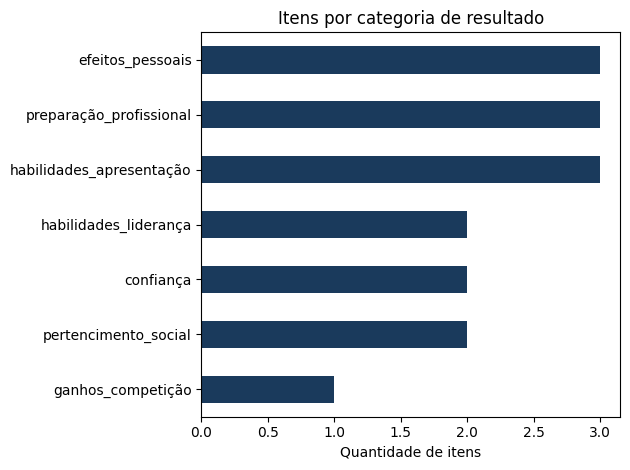

In [2]:
categorias = itens["categoria_resultado"].value_counts().rename_axis("categoria").to_frame("itens")
display(categorias)
categorias.sort_values("itens").plot.barh(legend=False, color="#1A3A5C", title="Itens por categoria de resultado")
plt.xlabel("Quantidade de itens")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Matriz de relações

Cada linha é uma tripla extraída das cadeias registradas nas anotações.

## Rede causal agregada

O grafo combina todas as sequências individuais e permite identificar fatores com maior
centralidade nas narrativas. Neste corpus, `Confianca`, `Habilidades_Lideranca` e
`Habilidades_Profissionais` emergem como os resultados mais frequentes; `Experiencias_De_Apresentacao`
e `Competicoes` figuram entre os antecedentes mais recorrentes.

As cores das arestas correspondem ao vocabulário de relações causais do projeto,
derivado das dimensões do Leeds Attributional Coding System (Munton et al., 1999)
e do modelo de Miles & Huberman (1994, p. 157).

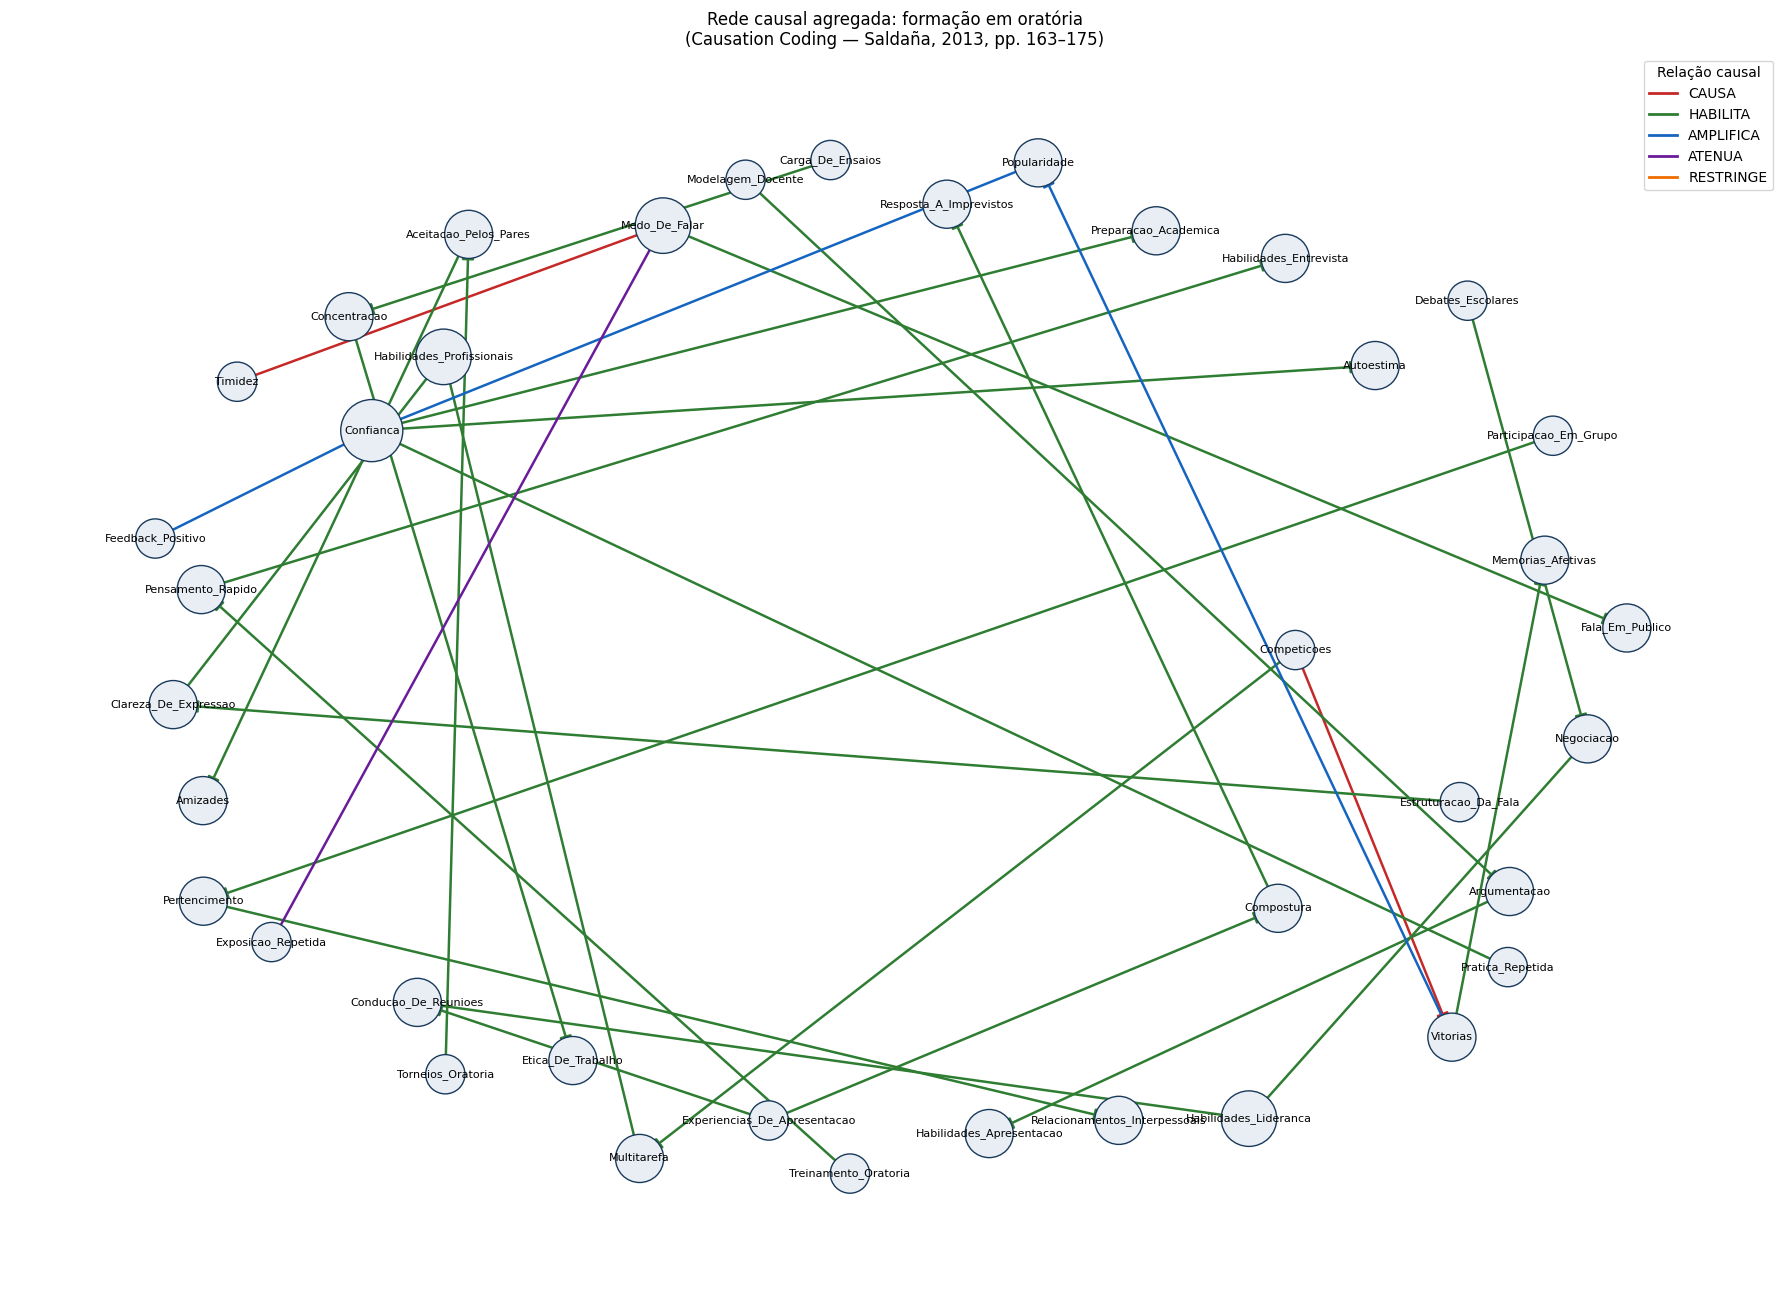

In [3]:
cores_relacao = {
    "CAUSA":     "#C62828",  # vermelho — geração direta
    "HABILITA":  "#2E7D32",  # verde — possibilitação
    "AMPLIFICA": "#1565C0",  # azul — reforço/intensificação
    "ATENUA":    "#6A1B9A",  # roxo — enfraquecimento/redução
    "RESTRINGE": "#EF6C00",  # laranja — bloqueio/impedimento
}

grafo = nx.DiGraph()
for linha in relacoes.itertuples(index=False):
    grafo.add_edge(linha.from_code, linha.to_code, relation=linha.relation)

# Tamanho dos nós proporcional ao grau de entrada (centralidade como resultado)
grau_entrada = dict(grafo.in_degree())
tamanhos = [800 + grau_entrada.get(n, 0) * 400 for n in grafo.nodes()]

posicoes = nx.spring_layout(grafo, seed=7, k=1.7)
plt.figure(figsize=(18, 13))
nx.draw_networkx_nodes(grafo, posicoes, node_color="#E8EEF4", edgecolors="#1A3A5C", node_size=tamanhos)
nx.draw_networkx_labels(grafo, posicoes, font_size=8)

for relacao, cor in cores_relacao.items():
    arestas = [
        (origem, destino)
        for origem, destino, dados in grafo.edges(data=True)
        if dados["relation"] == relacao
    ]
    if arestas:
        nx.draw_networkx_edges(
            grafo, posicoes, edgelist=arestas,
            edge_color=cor, width=1.8, arrowsize=18,
        )

plt.title("Rede causal agregada: formação em oratória\n(Causation Coding — Saldaña, 2013, pp. 163–175)")
legenda = [Line2D([0], [0], color=cor, lw=2, label=relacao) for relacao, cor in cores_relacao.items()]
plt.legend(handles=legenda, title="Relação causal")
plt.axis("off")
plt.tight_layout()
plt.show()

## Matriz antecedente → mediador → resultado

Saldaña (2013, pp. 169–171) recomenda reorganizar os códigos em uma matriz de três colunas
para identificar padrões entre antecedentes, mediadores e resultados no corpus completo.
A célula abaixo reproduz essa etapa usando os papéis definidos na ontologia do projeto.

In [4]:
# Colunas reais de "itens":  bibref, citação, resumo, chain, categoria_resultado, source_file, source_line, source_column
# Colunas reais de "relacoes": bibref, from_code, relation, to_code, source_file, source_line, source_column
# Colunas reais de "ontologia": chain (= conceito), descrição, papel, grupo, source_file, source_line, source_column

papel_no = ontologia.set_index("chain")["papel"].to_dict()

# Cada participante pode ter vários itens; cada item tem uma category.
# "relacoes" tem bibref mas não item_id — agrupamos por bibref e pegamos
# a categoria mais frequente do participante como proxy de contexto.
categoria_por_bibref = (
    itens.groupby("bibref")["categoria_resultado"]
    .agg(lambda s: s.mode().iloc[0])  # categoria mais frequente por participante
)

rel = relacoes.copy()
rel["papel_origem"] = rel["from_code"].map(papel_no).fillna("—")
rel["papel_destino"] = rel["to_code"].map(papel_no).fillna("—")
rel["antecedente"] = rel.apply(lambda r: r["from_code"] if r["papel_origem"] == "antecedente" else "—", axis=1)
rel["mediador"] = rel.apply(
    lambda r: r["from_code"] if r["papel_origem"] == "mediador"
    else (r["to_code"] if r["papel_destino"] == "mediador" else "—"),
    axis=1,
)
rel["resultado"] = rel.apply(lambda r: r["to_code"] if r["papel_destino"] == "resultado" else "—", axis=1)
rel["categoria"] = rel["bibref"].map(categoria_por_bibref)

matriz_tripla = (
    rel[rel["resultado"] != "—"][["bibref", "categoria", "antecedente", "mediador", "resultado", "relation"]]
    .rename(columns={"relation": "relação"})
    .drop_duplicates()
    .sort_values(["categoria", "antecedente"])
    .reset_index(drop=True)
)
display(matriz_tripla)

,bibref,categoria,antecedente,mediador,resultado,relação
0,@participante08,confiança,Vitorias,—,Memorias_Afetivas,HABILITA
1,@participante02,confiança,—,Aceitacao_Pelos_Pares,Amizades,HABILITA
2,@participante08,confiança,—,Medo_De_Falar,Fala_Em_Publico,HABILITA
3,@participante01,efeitos_pessoais,—,Medo_De_Falar,Fala_Em_Publico,RESTRINGE
4,@participante01,efeitos_pessoais,—,Pensamento_Rapido,Habilidades_Entrevista,HABILITA
5,@participante05,efeitos_pessoais,—,Concentracao,Etica_De_Trabalho,HABILITA
6,@participante05,efeitos_pessoais,—,Multitarefa,Habilidades_Profissionais,HABILITA
7,@participante06,efeitos_pessoais,—,Confianca,Autoestima,HABILITA
8,@participante06,efeitos_pessoais,—,Pertencimento,Relacionamentos_Interpessoais,HABILITA
9,@participante03,habilidades_apresentação,—,Confianca,Preparacao_Academica,HABILITA


## Macrocategorias analíticas

Após a categorização inicial, Saldaña (2013, p. 171) agrupa as categorias em dois conjuntos
de ordem superior com base em similaridade de outcome:

- **Preparação para o trabalho** (*Workforce Preparation*): `preparação_profissional`, `habilidades_apresentação`, `habilidades_liderança`
- **Preparação para a vida** (*Lifeforce Preparation*): `confiança`, `ganhos_competição`, `pertencimento_social`, `efeitos_pessoais`

> "CONFIDENCE emerged as the primary outcome from the majority of the 234 survey respondents
> in this particular study." (Saldaña, 2013, p. 172)

,macrocategoria,categoria,itens
0,Preparação para a vida,efeitos_pessoais,3
1,Preparação para a vida,pertencimento_social,2
2,Preparação para a vida,confiança,2
3,Preparação para a vida,ganhos_competição,1
4,Preparação para o trabalho,preparação_profissional,3
5,Preparação para o trabalho,habilidades_apresentação,3
6,Preparação para o trabalho,habilidades_liderança,2


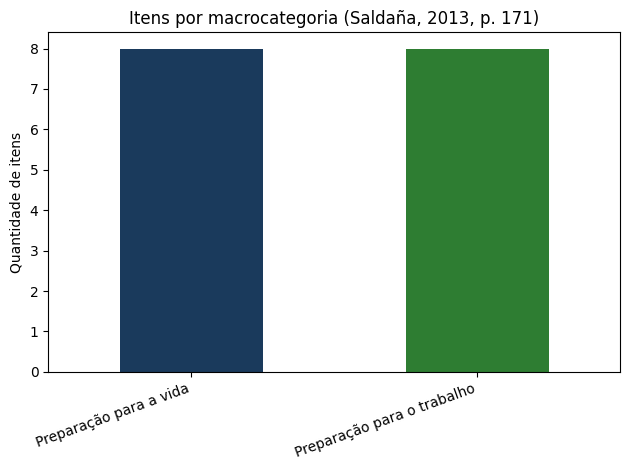

In [5]:
workforce = {"preparação_profissional", "habilidades_apresentação", "habilidades_liderança"}
lifeforce = {"confiança", "ganhos_competição", "pertencimento_social", "efeitos_pessoais"}

contagem = itens["categoria_resultado"].value_counts()

macro = pd.DataFrame({
    "macrocategoria": [
        "Preparação para o trabalho" if cat in workforce else "Preparação para a vida"
        for cat in contagem.index
    ],
    "categoria": contagem.index,
    "itens": contagem.values,
})

display(macro.sort_values(["macrocategoria", "itens"], ascending=[True, False]).reset_index(drop=True))

resumo_macro = macro.groupby("macrocategoria")["itens"].sum()
cores_macro = ["#1A3A5C", "#2E7D32"]
resumo_macro.plot.bar(color=cores_macro, title="Itens por macrocategoria (Saldaña, 2013, p. 171)")
plt.ylabel("Quantidade de itens")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()